# Nivel 3. Explicabilidad del modelo

Este notebook explica el comportamiento del modelo seleccionado con SHAP (`TreeExplainer`,
atribuciones exactas y aditivas para árboles). El modelo predice el cambio de la sílice respecto a la
última medición de laboratorio y reconstruye el nivel sumando ese cambio (ver notebook 02), así que las
atribuciones SHAP están en escala de cambio: cuántos puntos de sílice empuja cada variable hacia arriba
o hacia abajo frente a la hora anterior. Es la lectura operacionalmente más útil: el operador ya conoce
la última medición y lo que necesita saber es hacia dónde se mueve el proceso y por qué.

Se cubren explicaciones globales (qué variables mueven la predicción y en qué dirección), dependencias
de los drivers de proceso, dos explicaciones locales contrastantes (la subida y la bajada de sílice más
fuertes que el modelo anticipa) y una verificación de coherencia: si SHAP dice que una variable empuja
en cierta dirección, se perturba esa variable y se confirma que el modelo responde así.

Las explicaciones se calculan sobre el conjunto de test (comportamiento de despliegue).

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd()
while not (_root / "config" / "config.yaml").exists():
    if _root == _root.parent:
        raise RuntimeError("No se encontro la raiz del proyecto")
    _root = _root.parent
sys.path.insert(0, str(_root))

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from src.config import load_config, resolve, set_seeds
from src.models.train import fit_winner
from src.explain.shap_analysis import compute_shap, driver_table, contrasting_cases

cfg = load_config(); set_seeds(cfg["seed"])
TARGET = cfg["data"]["target"]; FIG = resolve(cfg["paths"]["figures_dir"])
model, data = fit_winner(cfg)
X_test, y_test = data["X_test"], data["y_test"]
# SHAP explica el booster interno: atribuciones en escala de cambio de la sílice.
explainer, sv = compute_shap(model.base_model, X_test)
print("Casos de test explicados:", X_test.shape)
print("Valor base E[delta] = %.4f (el cambio esperado es ~0: la planta es estable la mayor parte del tiempo)"
      % float(explainer.expected_value))

Casos de test explicados: (614, 110)
Valor base E[delta] = 0.0002 (el cambio esperado es ~0: la planta es estable la mayor parte del tiempo)


## 1. Importancia global (media de |SHAP|)

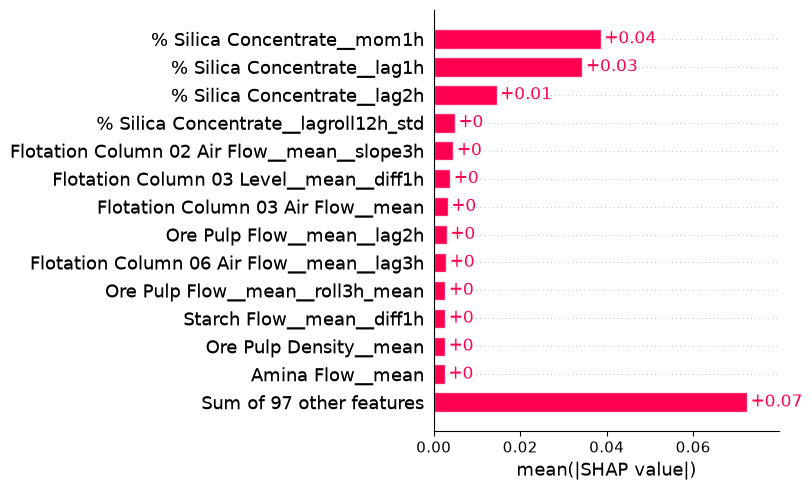

In [2]:
shap.plots.bar(sv, max_display=14, show=False)
fig = plt.gcf(); fig.set_size_inches(8, 5); fig.tight_layout()
fig.savefig(FIG / "03_shap_bar.png", dpi=110); plt.show()

In [3]:
drivers = driver_table(sv, X_test)
target_hist = drivers["feature"].str.startswith(TARGET)
lag_share = drivers[target_hist]["mean_abs_shap"].sum() / drivers["mean_abs_shap"].sum()
print("Cuota de la historia del target en la magnitud SHAP total: %.0f%%" % (100 * lag_share))
print("Cuota de variables de proceso: %.0f%%" % (100 * (1 - lag_share)))
drivers.head(12).round(4)

Cuota de la historia del target en la magnitud SHAP total: 48%
Cuota de variables de proceso: 52%


,feature,mean_abs_shap,direction
0,% Silica Concentrate__mom1h,0.0386,-1.0
1,% Silica Concentrate__lag1h,0.0344,-1.0
2,% Silica Concentrate__lag2h,0.0145,-1.0
3,% Silica Concentrate__lagroll12h_std,0.0049,-1.0
4,Flotation Column 02 Air Flow__mean__slope3h,0.0045,-1.0
5,Flotation Column 03 Level__mean__diff1h,0.0038,1.0
6,Flotation Column 03 Air Flow__mean,0.0032,-1.0
7,Ore Pulp Flow__mean__lag2h,0.0030,1.0
8,Flotation Column 06 Air Flow__mean__lag3h,0.0029,-1.0
9,Ore Pulp Flow__mean__roll3h_mean,0.0027,1.0


A diferencia del modelo de nivel, donde el lag de 1 hora concentraba la mayor parte de la magnitud
explicativa, en el modelo de cambio el reparto es más equilibrado: la dinámica reciente del target
(momentum, lags, medias móviles) explica la parte inercial del movimiento y las variables de proceso
ganan protagonismo para explicar hacia dónde se desvía la sílice de su trayectoria. La columna
`direction` indica el sentido operacional: +1 significa que valores mayores de la variable empujan la
sílice hacia arriba respecto a la hora anterior.

## 2. Beeswarm: distribución de efectos

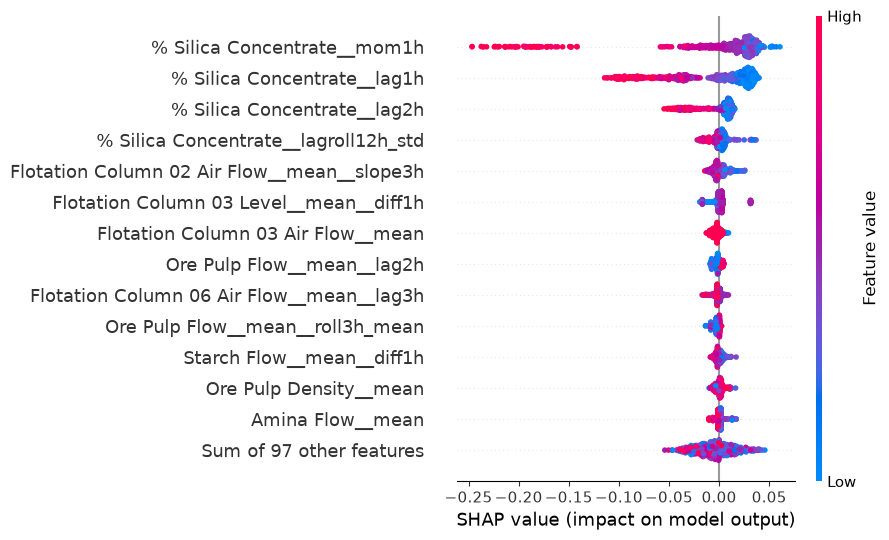

In [4]:
shap.plots.beeswarm(sv, max_display=14, show=False)
fig = plt.gcf(); fig.set_size_inches(9, 5.5); fig.tight_layout()
fig.savefig(FIG / "03_shap_beeswarm.png", dpi=110); plt.show()

Lectura operacional de los drivers, en escala de cambio respecto a la hora anterior:

- Dinámica reciente de la sílice (momentum y lags, signo negativo): tras horas altas o subidas fuertes
  el modelo anticipa una reversión parcial hacia la media reciente, la corrección de inercia esperable
  en un proceso estable.
- Aireación de las columnas (nivel medio y pendiente de 3 h, signo negativo): más aire, o aire en
  ascenso, se asocia a empujes a la baja de la sílice. Es consistente con la flotación inversa de este
  proceso: el aire hace flotar la ganga silícea hacia la espuma de descarte y limpia el concentrado.
- Nivel de columna en ascenso (cambio de 1 h, signo positivo): subidas del nivel se asocian a empujes
  al alza de la sílice, coherente con una espuma más delgada que remueve menos ganga.
- Flujo y densidad de pulpa (signo positivo): más carga implica menor tiempo de residencia y empuja la
  sílice esperada hacia arriba; dosis de almidón en ascenso empujan a la baja.

Son asociaciones aprendidas de la operación histórica, no relaciones causales garantizadas.

## 3. Dependencias de los drivers principales

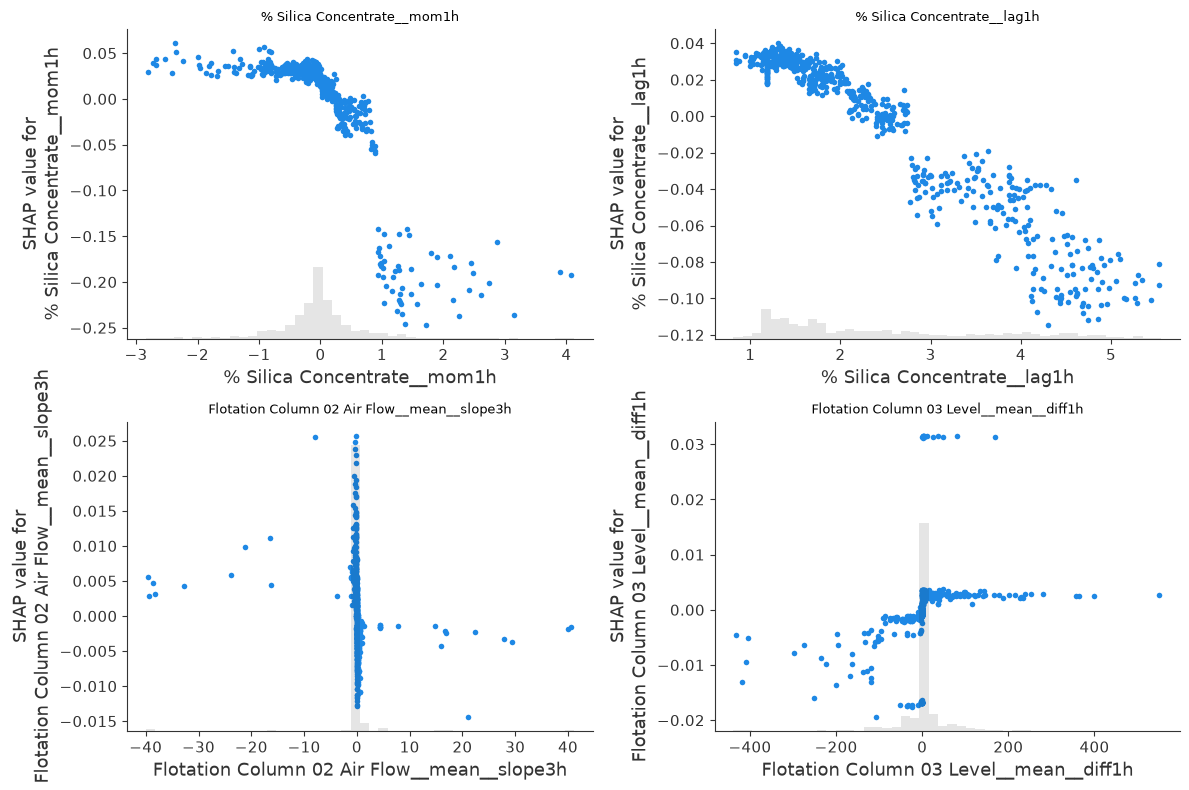

In [5]:
# Los dos primeros drivers de historia del target y los dos primeros de proceso.
hist_feats = drivers[target_hist]["feature"].head(2).tolist()
proc_feats = drivers[~target_hist]["feature"].head(2).tolist()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.ravel(), hist_feats + proc_feats):
    shap.plots.scatter(sv[:, feat], ax=ax, show=False)
    ax.set_title(feat, fontsize=9)
fig.tight_layout(); fig.savefig(FIG / "03_dependence.png", dpi=110); plt.show()

Las dependencias de la historia del target muestran la corrección de inercia (pendiente negativa frente
al momentum: lo que subió mucho tiende a devolver parte). Las de proceso son no lineales y de menor
pendiente: modulan el cambio sin dominarlo, igual que en la operación real, donde un setpoint no
revierte por sí solo una tendencia de calidad.

## 4. Explicaciones locales contrastantes

Los dos casos más informativos en escala de cambio: la hora en que el modelo anticipa la mayor subida
de sílice y la hora en que anticipa la mayor bajada.

Mayor SUBIDA anticipada: 2017-09-02 19:00:00 (delta predicho +0.14)
Mayor BAJADA anticipada: 2017-08-18 16:00:00 (delta predicho -0.44)


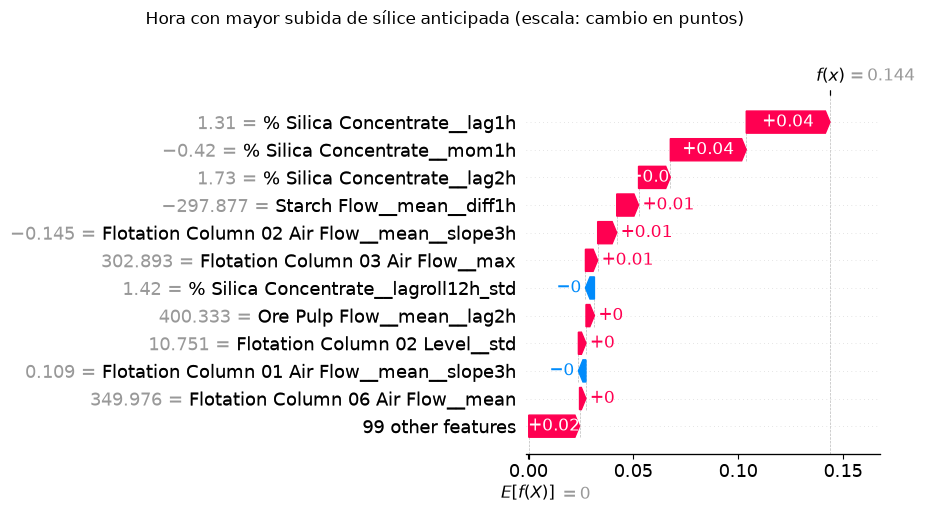

In [6]:
cases = contrasting_cases(model.base_model, X_test)
print("Mayor SUBIDA anticipada: %s (delta predicho %+.2f)" % (cases["high"], cases["high_pred"]))
print("Mayor BAJADA anticipada: %s (delta predicho %+.2f)" % (cases["low"], cases["low_pred"]))
idx_high = X_test.index.get_loc(cases["high"])
idx_low = X_test.index.get_loc(cases["low"])

shap.plots.waterfall(sv[idx_high], max_display=12, show=False)
fig = plt.gcf(); fig.set_size_inches(9, 5)
fig.suptitle("Hora con mayor subida de sílice anticipada (escala: cambio en puntos)", y=1.02)
fig.tight_layout(); fig.savefig(FIG / "03_waterfall_high.png", dpi=110, bbox_inches="tight"); plt.show()

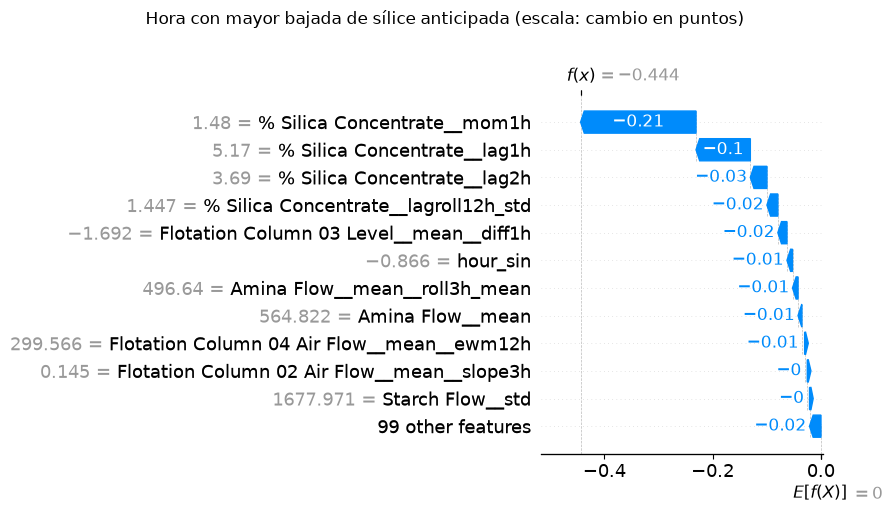

In [7]:
shap.plots.waterfall(sv[idx_low], max_display=12, show=False)
fig = plt.gcf(); fig.set_size_inches(9, 5)
fig.suptitle("Hora con mayor bajada de sílice anticipada (escala: cambio en puntos)", y=1.02)
fig.tight_layout(); fig.savefig(FIG / "03_waterfall_low.png", dpi=110, bbox_inches="tight"); plt.show()

Cada cascada parte del cambio esperado promedio (cercano a cero) y muestra qué empujó la predicción de
esa hora, variable por variable y en puntos de sílice. Esta es la traducción operacional del modelo
delta: ante una alerta de subida, el operador ve qué variables la explican y cuáles de ellas son
accionables (ver notebook 04).

## 5. Verificación de coherencia entre SHAP y el comportamiento del modelo

In [8]:
# Se toma un caso, se perturba cada variable en una desviación estándar observada y se
# verifica que la predicción (en escala de nivel) se mueva en el sentido que indica SHAP.
proc_check = drivers[~target_hist].head(3)
base_row = X_test.loc[[cases["low"]]].copy()
base_pred = float(model.predict(base_row)[0])
checks = []
for feat, direction in zip(proc_check["feature"], proc_check["direction"]):
    delta = X_test[feat].std()  # una desviación estándar observada de movimiento
    up = base_row.copy(); up[feat] = up[feat] + delta
    new_pred = float(model.predict(up)[0])
    checks.append({"feature": feat, "shap_direction": int(direction),
                   "delta_feature": round(float(delta), 3),
                   "delta_pred": round(new_pred - base_pred, 4),
                   "coherente": bool(np.sign(new_pred - base_pred) == direction
                                     or abs(new_pred - base_pred) < 1e-6)})
pd.DataFrame(checks)

,feature,shap_direction,delta_feature,delta_pred,coherente
0,Flotation Column 02 Air Flow__mean__slope3h,-1,5.087,0.0000,True
1,Flotation Column 03 Level__mean__diff1h,1,72.756,0.0892,True
2,Flotation Column 03 Air Flow__mean,-1,14.127,0.0000,True


Al aumentar cada driver de proceso en una desviación estándar, la predicción se mueve en el sentido que
indica el signo de su dependencia SHAP. El modelo se comporta de forma consistente con sus
explicaciones, lo que respalda usarlas para guiar decisiones (ver notebook 04).